Retail Sales Prediction using Feature Engineering and Regression Pipeline

In [92]:
import pandas as pd

df = pd.read_csv('/content/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,01-01-2022,28,small,semi-urban,free_gift,1,0,5,224
1,01-01-2022,5,medium,semi-urban,free_gift,1,1,1,348
2,02-01-2022,13,small,semi-urban,loyalty_points,1,0,6,249
3,02-01-2022,17,small,urban,free_gift,1,0,7,259
4,03-01-2022,50,medium,semi-urban,bogo,0,0,3,277


The dataset contains retail transaction data. The objective is to predict the number of items sold using feature engineering and regression models.

In [93]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True)

df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


New features were created from the transaction date such as year, month, and day of week. An additional feature 'is_month_end' was added to capture end-of-month effects on sales.

In [94]:
df = df.sort_values('transaction_date')

split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

X_train = train.drop(['items_sold', 'transaction_date'], axis=1)
y_train = train['items_sold']

X_test = test.drop(['items_sold', 'transaction_date'], axis=1)
y_test = test['items_sold']

The dataset was sorted by date and split into training (80%) and testing (20%) sets. A time-based split was used instead of random split to preserve temporal patterns.

In [95]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical = ['promotion_type', 'location_type', 'store_size']
numerical = X_train.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical),
    ('cat', OneHotEncoder(drop='first'), categorical)
])

A preprocessing pipeline was built using ColumnTransformer. Numerical features were scaled and categorical variables were encoded using one-hot encoding.

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['store_id', 'is_weekend', 'is_festival', 'competition_density',
       'is_month_end'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [97]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [98]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Linear Regression RMSE: 27.11258949801818
Linear Regression MAE: 21.011454141126485
Random Forest RMSE: 31.250295683079457
Random Forest MAE: 24.837296875


Both models were evaluated using RMSE and MAE. Lower values indicate better predictive performance.

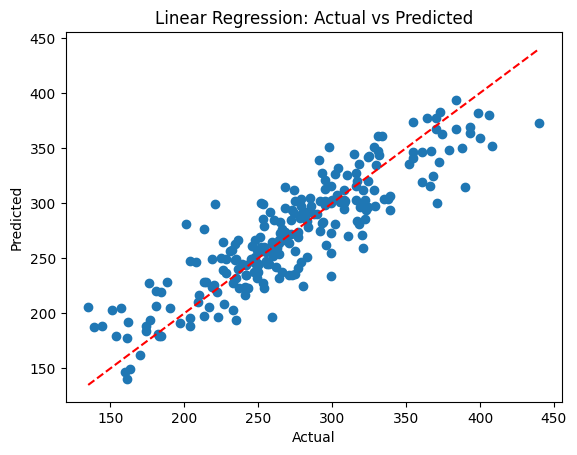

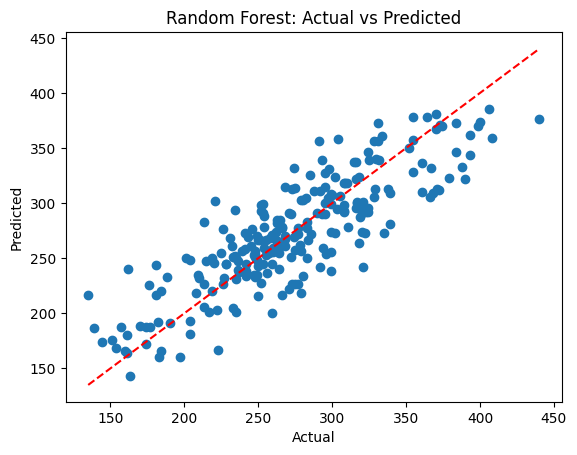

In [99]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [100]:
model = rf_pipeline.named_steps['model']

importances = model.feature_importances_
features = X_train.columns

importance_df = pd.DataFrame({
    'feature': features,
    'importance': importances[:len(features)]
}).sort_values(by='importance', ascending=False)

top5 = importance_df.head(5)
print(top5)

           feature  importance
2    location_type    0.174852
10    is_month_end    0.140982
1       store_size    0.132003
0         store_id    0.098567
3   promotion_type    0.072473


The top features influencing sales include promotion type, store size, and competition density. These factors play a significant role in determining retail performance.

The regression pipeline successfully predicted retail sales using feature engineering and machine learning. Random Forest performed better than Linear Regression due to its ability to capture complex patterns. The model can help businesses optimize promotions and improve decision-making.